# Deep Active Learning Using Semi-Supervised Classification

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cells to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml[opt] torch torchvision tqdm datasets transformers

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

This tutorial aims to demonstrate a practical comparison study using our
```scikit-activeml``` library. The main focus of this notebook is the use
of the `semi_supervised` subpackage of `scikit-learn` (see 
[here](https://scikit-learn.org/stable/modules/semi_supervised.html)), that
offers wrapper classes for classifiers, enabling the use of unlabeled data.
The basic structure and data preparation of this notebook closely follows the
[Deep Active Learning with Frozen Vision Transformer notebook](https://scikit-activeml.github.io/latest/generated/tutorials/05_pool_al_with_self_supervised_learning.html) while using a different dataset (Food101 [1]).

[1] Bossard, L. and Guillaumin, M. and Van Gool, L. (2014). Food-101 - Mining Discriminative Components with Random Forests. European Conference on Computer Vision.

In [2]:
# Comment in for speedup, if you have cuML installed.
# %load_ext cuml.accel
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import torch
import warnings

from datasets import load_dataset
from multiprocess import set_start_method
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from skactiveml.classifier import SklearnClassifier
from skactiveml.pool import (
    UncertaintySampling,
    RandomSampling,
    CoreSet,
    TypiClust,
    DropQuery,
    ProbCover,
    Falcun,
    SubSamplingWrapper,
)
from skactiveml.utils import call_func
from transformers import AutoImageProcessor, Dinov2Model
from tqdm import tqdm
from threadpoolctl import threadpool_limits


set_start_method("spawn", force=True)
threadpool_limits(limits=1, user_api="blas")
warnings.filterwarnings("ignore")
mlp.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"

## Embed FOOD-101 Images with DINOv2

In this step, we focus on preparing the datasets using the self-supervised
learning model DINOv2. DINOv2, short for "self-distillation with no labels",
 is a popular vision foundation model that excels at providing meaningful
 representations for image data.

In [3]:
# Download data.
ds = load_dataset("ethz/food101")

# Download DINOv2 ViT/S-14 as embedding model.
processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-small", use_fast=True
)
model = Dinov2Model.from_pretrained("facebook/dinov2-small").to(device).eval()


# Embed Food-101 images.
def embed(batch, processor, device, model):
    import torch

    inputs = processor(images=batch["image"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs).last_hidden_state[:, 0]
    return {"emb": out.cpu().numpy()}


embed_kwargs = {
    "processor": processor,
    "model": model,
    "device": device,
}
ds = ds.map(
    embed,
    batched=True,
    batch_size=64,
    num_proc=2,
    fn_kwargs=embed_kwargs,
    remove_columns=["image"],
)
X_pool = np.stack(ds["train"]["emb"], dtype=np.float32)
y_pool = np.array(ds["train"]["label"], dtype=np.int64)
X_test = np.stack(ds["validation"]["emb"], dtype=np.float32)
y_test = np.array(ds["validation"]["label"], dtype=np.int64)

## Random Seed Management

To ensure experiment reproducibility, it's important to set random states for all components that might use them. For simplicity, we set a single fixed random state and use helper functions to generate new seeds and random states. It's important to note that the ```master_random_state``` should only be used to create new random states or random seeds.

In [4]:
master_random_state = np.random.RandomState(0)


def gen_seed(random_state: np.random.RandomState):
    """
    Generate a seed for a random number generator.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - int: Generated seed.
    """
    return random_state.randint(0, 2**31)


def gen_random_state(random_state: np.random.RandomState):
    """
    Generate a new random state object based on a given random state.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - np.random.RandomState: New random state object.
    """
    return np.random.RandomState(gen_seed(random_state))

## Classification Models and Query Strategies

The embeddings we have computed can be used as an input to a classification model. For this guide, we use `LogisticRegression` from `sklearn.linear_model`. Moreover, we handle the creation of query strategies using factory functions to simplify the separation of query strategies across repetitions. We use `missing_label=-1` because the wrappers in `scikit-learn.semi_supervised` only supports -1 as a placeholder label for unlabeled samples.

In [5]:
n_features, classes = X_pool.shape[1], np.unique(y_pool)
missing_label = -1

# Define classifiers to use for experiments
def create_classifier(name, classes, random_state):
    return classifier_factory_functions[name](classes, random_state)
classifier_factory_functions = {
    'LogisticRegression': lambda classes, random_state: SklearnClassifier(
        LogisticRegression(
            verbose=0,
            tol=1e-3,
            C=0.1,
            max_iter=10000,
            random_state=gen_seed(random_state)
        ),
        classes=classes,
        random_state=gen_seed(random_state),
        missing_label=missing_label
    )
}

# Define query strategies for experiments
def create_query_strategy(name, random_state):
    return query_strategy_factory_functions[name](random_state)
query_strategy_factory_functions = {
    "RandomSampling": lambda random_state: RandomSampling(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    "UncertaintySampling": lambda random_state: UncertaintySampling(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    "CoreSet": lambda random_state: CoreSet(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    "TypiClust": lambda random_state: TypiClust(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    "DropQuery": lambda random_state: DropQuery(
        random_state=gen_seed(random_state),
        missing_label=missing_label,
    ),
    "ProbCover": lambda random_state: ProbCover(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    "Falcun": lambda random_state: Falcun(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
}

## Experiment Parameters

For this experiment, we need to define how the strategies should be compared against one another. Here the number of repetitions (```n_reps```), the number of cycles (```n_cycles```), and the size of each query (```query_batch_size```) need to be defined. 

In [6]:
n_reps = 3
n_cycles = 20
query_batch_size = 100
classifier_names = classifier_factory_functions.keys()
query_strategy_names = query_strategy_factory_functions.keys()

## Experiment Loop

The actual experiment loops over all query strategies. The accuracy for the test set is stored for each cycle and repetition in the `results` dictionary. Here, we execute the experiments with and without `SelfTraining` (`use_ssl_clf`). This wrapper includes unlabeled samples into the labeled pool for training (i.e., not for querying new labels). The wrapped classifier is iteratively trained `SelfTrainingClassifier.max_iter` times and in each iteration new unlabeled samples whose prediciton for a class exceed `SelfTrainingClassifier.threshold` will be included in the labeled pool for the next training iteration. In this notebook, the number of iterations of self-training scales with the number of active learning cycles, such that it starts with 1 iteration at cycle 6 and caps at cycle 10 and above with 5 iterations.

In [7]:
results = {}
for clf_name in classifier_names:
    for use_ssl_clf in [True, False]:
        for qs_name in query_strategy_names:
            accuracies = np.full((n_reps, n_cycles + 1), np.nan)
            for i_rep in range(n_reps):
                # initialize labels
                y_train = np.full(shape=len(X_pool), fill_value=missing_label)

                # initialize query strategy qs with subsampling
                qs = create_query_strategy(
                    qs_name,
                    random_state=gen_random_state(np.random.RandomState(i_rep)),
                )
                qs = SubSamplingWrapper(
                    query_strategy=qs,
                    missing_label=missing_label,
                    random_state=gen_random_state(np.random.RandomState(i_rep)),
                    exclude_non_subsample=True,
                    max_candidates=0.1,
                )
                # initialize classifier with or without self-training
                raw_clf = create_classifier(
                    clf_name,
                    classes,
                    gen_random_state(master_random_state)
                )
                if use_ssl_clf:
                    # wrap classifier with SelfTrainingClassifier
                    clf = SklearnClassifier(
                        SelfTrainingClassifier(
                            raw_clf,
                            threshold=0.95,
                            max_iter=0,
                        ),
                        include_unlabeled_samples=True,
                        classes=classes,
                        random_state=gen_random_state(np.random.RandomState(i_rep)),
                        missing_label=missing_label
                    )
                else:
                    # Use regular classifier without wrapping it
                    clf=raw_clf
                # Train and evaluate classifier without additionally queried data
                clf.fit(X_pool, y_train)
                accuracies[i_rep, 0] = clf.score(X_test, y_test)

                for c in tqdm(
                    range(1, n_cycles + 1), desc=f"Repeat {i_rep + 1} with {qs_name}"
                ):
                    # Query labels
                    query_idx = call_func(
                        qs.query,
                        X=X_pool,
                        y=y_train,
                        batch_size=query_batch_size,
                        clf=clf,
                        discriminator=clf,
                        update=True,
                        fit_clf=False
                    )
                    y_train[query_idx] = y_pool[query_idx]
                    # Set the number of iterations for SelfTraining
                    if use_ssl_clf:
                        clf.estimator.set_params(max_iter=min(max(0, c-5), 5))
                    clf.fit(X_pool, y_train)
                    accuracies[i_rep, c] = clf.score(X_test, y_test)

            results[(clf_name, use_ssl_clf, qs_name)] = accuracies

Repeat 3 with Falcun: 100%|██████████| 20/20 [00:02<00:00,  7.74it/s]


## Resulting Plotting

We use learning curves to compare strategies. We visualize the average accuracy over all repetitions. In addition, the legend provides insight into the area under the learning curve, which indicates the average accuracy over all cycles. For this notebook we utilize dotted lines to show the average learning curves for experiments without a semi-supervised classifier while learning curves for classifiers wrapped with `SelfTrainingClassifier` are plotted using continous lines.

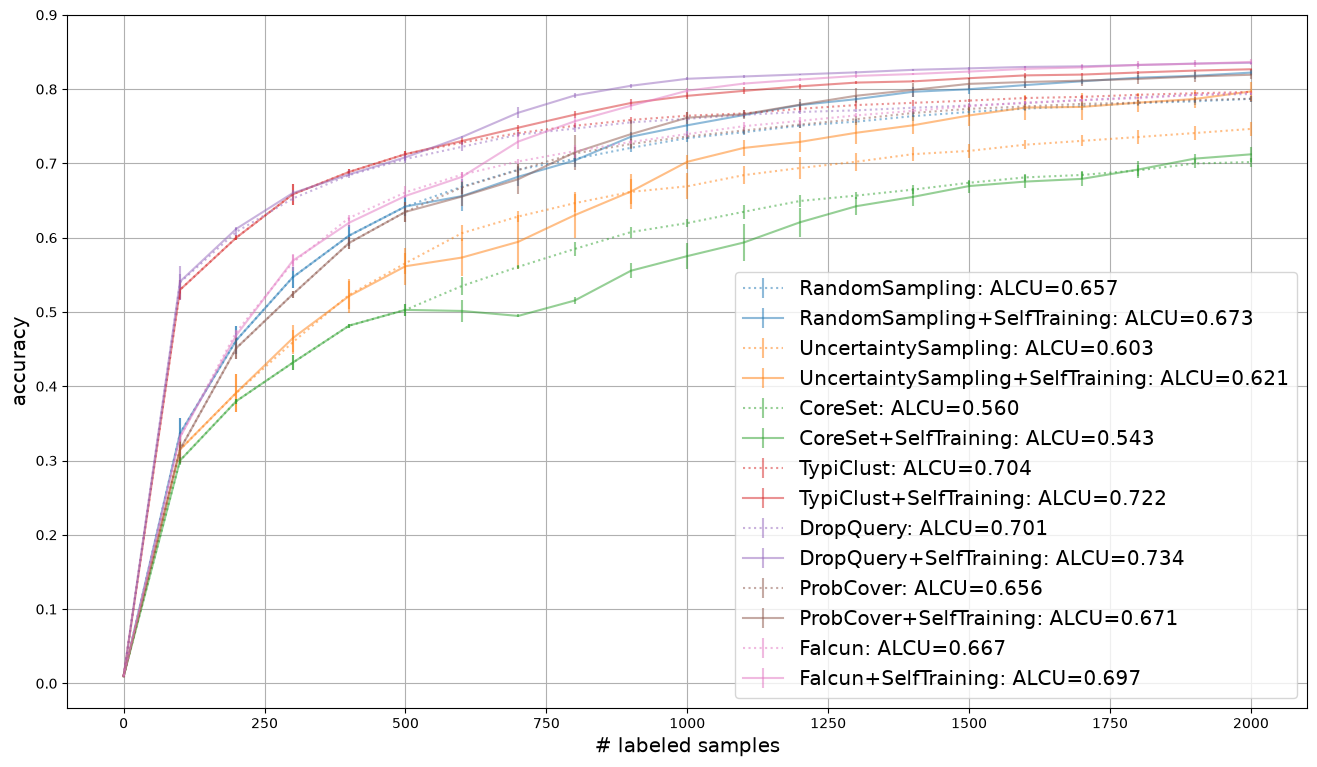

In [8]:
for clf_name in classifier_names:
    plt.figure(figsize=(16, 9))
    for i_qs, qs_name in enumerate(query_strategy_names):
        for use_ssl in [False, True]:
            key = (clf_name, use_ssl, qs_name)
            result = results[key]
            reshaped_result = result.reshape((-1, n_cycles + 1))
            errorbar_mean = np.mean(reshaped_result, axis=0)
            errorbar_std = np.std(reshaped_result, axis=0)
            linestyle = ':'
            display_name = qs_name
            color = f'C{i_qs}'
            if use_ssl:
                linestyle = '-'
                display_name = qs_name+'+SelfTraining'

            plt.errorbar(
                np.arange(n_cycles + 1) * query_batch_size,
                errorbar_mean,
                errorbar_std,
                label=f"{display_name}: ALCU={np.mean(errorbar_mean):.3f}",
                alpha=0.5,
                color=color,
                linestyle=linestyle
            )
            plt.yticks(np.arange(0, 1.0, 0.1))
    plt.grid()
    plt.legend(loc="lower right", fontsize="x-large")
    plt.xlabel("# labeled samples", fontsize="x-large")
    plt.ylabel("accuracy", fontsize="x-large")
    plt.show()